# Capstone — Ranking the next 30 days of content decline

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tu-h-nguyn/FlyRank-Machine-Learning-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Lane 2 — Refresh / Content Opportunity Scoring.**
Notebook này là bản song song của research paper đã deploy: mỗi mục ở đây là một mục trong paper,
và mọi con số trong paper đều sinh ra từ đúng những cell dưới đây.

- Paper (deployed): xem `submission/paper_url.txt`
- Toàn bộ logic: `work/scripts/capstone_pipeline.py` (một file, seed = 42)
- Receipts: `work/outputs/*.json` — commit trong repo, không phải tin lời tôi

**Abstract (5 câu).** Khi một đội biên tập chỉ rà soát được vài chục trang mỗi tuần, câu hỏi thật không
phải "trang nào đang tệ" mà là "trang nào nên xem trước". Tôi dùng slice ẩn danh công khai của FlyRank
(30,000 trang × 44 cột, 32 client, một snapshot 90 ngày), tách cửa sổ 90 ngày thành ba đoạn 30 ngày và
chỉ giữ lại những tín hiệu **biết được tại thời điểm ra quyết định** để dự báo trang nào sẽ mất hơn 20%
impressions trong 30 ngày kế tiếp. Một mô hình hồi quy logistic trên 24 đặc trưng như vậy, chấm
out-of-fold với split nhóm theo client, xếp đúng **88% trong 50 trang đầu** so với **74%** của rule
baseline minh bạch và **61.6%** base rate — trong khi chính rule của tuần 4 (dựa trên `days_since_last_update`
và tổng 90 ngày) hóa ra **không có khả năng xếp hạng nào cả (ROC-AUC 0.500)** vì nó đọc những cột chồng
lấn cửa sổ kết quả. Thêm lại đúng những cột đó đẩy Precision@200 lên 0.995 — một điểm số đẹp mà tôi
không được phép công bố. Kết quả là một hàng đợi 18,010 trang có reason code, hành động đề xuất và mức
tin cậy, dùng để **hỗ trợ thứ tự rà soát**, không phải để hứa rằng refresh sẽ khôi phục lưu lượng.

## 1. Question

**Câu hỏi nghiên cứu:**

> Đứng ở đầu một cửa sổ 30 ngày và chỉ dùng những gì biết được tại thời điểm đó, ta có xếp hạng được
> các trang theo khả năng mất hơn 20% impressions trong 30 ngày kế tiếp tốt hơn một quy tắc minh bạch
> mà con người đọc được không?

**Quyết định mà nó hỗ trợ:** biên tập viên có năng lực hữu hạn (ví dụ 50 trang/tuần) phải chọn **thứ tự**
rà soát. Đầu ra là một hàng đợi xếp hạng, mỗi dòng kèm lý do — không phải một lệnh phải làm.

**Đơn vị phân tích (grain):** một trang nội dung ẩn danh (`content_id`) trong một snapshot.

**Cái giá của việc sai:**
- *Báo động giả* — biên tập viên tốn một giờ cho trang không cần sửa, và can thiệp vào một trang đang ổn định.
- *Bỏ sót* — một trang có nhu cầu thật suy giảm âm thầm cho tới khi việc khôi phục trở nên đắt đỏ.

Vì hai cái giá đó không đối xứng theo K, chỉ số phải là **precision@K** ở đúng mức K bằng năng lực thật
của đội, kèm base rate đứng ngay bên cạnh.

In [1]:
# --- Bootstrap: chạy được cả ở local lẫn trên Colab ---
import os, sys, urllib.request

BRANCHES = [
    "https://raw.githubusercontent.com/tu-h-nguyn/FlyRank-Machine-Learning-Internship/main",
    "https://raw.githubusercontent.com/tu-h-nguyn/FlyRank-Machine-Learning-Internship/claude/search-ranking-capstone-166z1j",
]

def _pipeline_dir() -> str:
    """Toàn bộ logic capstone nằm trong MỘT file: work/scripts/capstone_pipeline.py."""
    for p in ["../scripts", "work/scripts", "scripts", "../../work/scripts"]:
        if os.path.exists(os.path.join(p, "capstone_pipeline.py")):
            return p
    os.makedirs("work/scripts", exist_ok=True)
    for base in BRANCHES:
        try:
            urllib.request.urlretrieve(f"{base}/work/scripts/capstone_pipeline.py",
                                       "work/scripts/capstone_pipeline.py")
            return "work/scripts"
        except Exception:
            continue
    raise RuntimeError("Không tải được capstone_pipeline.py")

sys.path.insert(0, _pipeline_dir())
import numpy as np
import pandas as pd
import capstone_pipeline as cp

raw = cp.load_raw()
frame = cp.build_frame(raw)
d, population = cp.apply_population_filter(frame)
y = d["label_declined"].to_numpy()
groups = d["client_id"].to_numpy()
X = cp.design_matrix(d)

print(f"Population: {population['rows_modelled']:,} trang / {population['clients_modelled']} client "
      f"(lọc từ {population['rows_start']:,} dòng, ngưỡng impressions_prev_30d >= {cp.MIN_PREV_IMPRESSIONS})")
print(f"Base rate (tỷ lệ trang thực sự suy giảm > 20% trong 30 ngày kế tiếp): {y.mean():.4f}")

print("\n--- KHUNG QUYẾT ĐỊNH ---")
print(f"Đơn vị phân tích       : một content_id (trang ẩn danh)")
print(f"Thời điểm ra quyết định: đầu cửa sổ 30 ngày gần nhất")
print(f"Nhãn                   : impressions giảm > {abs(cp.DECLINE_THRESHOLD_PCT):.0f}% ở 30 ngày kế tiếp")
print(f"Chỉ số                 : Precision@K (K = năng lực rà soát thật), luôn kèm base rate")
print(f"Base rate              : {y.mean():.4f}  ({int(y.sum()):,}/{len(y):,} trang thực sự suy giảm)")
print(f"Ngưỡng ngẫu nhiên      : chọn bừa 50 trang => kỳ vọng đúng {y.mean()*50:.1f}/50 trang")

Population: 18,010 trang / 30 client (lọc từ 30,000 dòng, ngưỡng impressions_prev_30d >= 100)
Base rate (tỷ lệ trang thực sự suy giảm > 20% trong 30 ngày kế tiếp): 0.6155

--- KHUNG QUYẾT ĐỊNH ---
Đơn vị phân tích       : một content_id (trang ẩn danh)
Thời điểm ra quyết định: đầu cửa sổ 30 ngày gần nhất
Nhãn                   : impressions giảm > 20% ở 30 ngày kế tiếp
Chỉ số                 : Precision@K (K = năng lực rà soát thật), luôn kèm base rate
Base rate              : 0.6155  (11,086/18,010 trang thực sự suy giảm)
Ngưỡng ngẫu nhiên      : chọn bừa 50 trang => kỳ vọng đúng 30.8/50 trang


## 2. Data

**Nguồn:** `data/raw/content_refresh_anonymized.csv` — slice ẩn danh công khai đi kèm repo starter:
30,000 trang × 44 cột, 32 client ẩn danh, một cửa sổ trượt 90 ngày (GSC + GA4).

**Vì sao không dùng warehouse 79M dòng:** release đầy đủ trên Hugging Face bị gated và cần `HF_TOKEN`;
môi trường chạy capstone này không có token, nên tôi công bố kết quả trên slice công khai và giữ nguyên
đường đi tới warehouse trong code (`cp.load_raw()` chỉ đổi nguồn, hợp đồng đặc trưng giữ nguyên).
Đây là một **giới hạn được nêu rõ**, không phải một chi tiết bị giấu.

**Phát hiện nền tảng — cửa sổ 90 ngày tách được chính xác:**

```text
impressions_90d  =  first30 (ngày 61-90 trước)  +  prev30 (ngày 31-60 trước)  +  last30 (ngày 1-30 trước)
                    \________ biết được _________/     \_____ biết được _____/    \____ CỬA SỔ NHÃN ____/
```

Đây là điều mở khóa toàn bộ capstone: nó cho phép tái tạo một "thời điểm ra quyết định" thật bên trong
một snapshot cắt ngang. Mọi tổng `*_90d` đều **chứa** cửa sổ nhãn, nên chúng bị loại; `first30` và `prev30`
thì hợp lệ.

**Đã loại và vì sao (danh sách đầy đủ in ở cell dưới):** cột dẫn xuất từ nhãn (`trend_pct`,
`trend_direction`), mọi tổng và tỷ lệ 90 ngày (`impressions_90d`, `ctr`, `avg_position`,
`engagement_rate`, `scroll_rate`, `ai_traffic_pct`, ...), mọi cột của 30 ngày cuối, các product tier
(`impression_tier`, `position_tier`, `freshness_tier`), và ID (chỉ để nhóm/split).

**Trường hợp đau nhất — `days_since_last_update`:** đây đúng là tín hiệu mà rule tuần 4 của tôi dựa vào.
Nhưng nó được đo lúc export, và **20,480/30,000 trang (68.3%) được cập nhật bên trong chính cửa sổ kết quả**.
Nó biết chuyện tương lai. Loại.

**Bộ lọc dân số:** giữ các trang có `impressions_prev_30d >= 100` — ngưỡng nhu cầu tối thiểu để một
suy giảm đáng để biên tập viên bỏ một giờ ra xem. Loại 11,990 trang, còn **18,010 trang / 30 client**.
Bộ lọc chỉ dùng cột của cửa sổ TRƯỚC thời điểm ra quyết định, nên không mang thông tin tương lai.

**An toàn công khai:** không có tên khách hàng, domain, URL, tiêu đề hay truy vấn nào trong bất kỳ đầu ra nào.
`content_id` / `client_id` là mã giả danh, chỉ dùng để nhóm và split.

In [2]:
# --- Chứng minh phép tách cửa sổ là chính xác, không phải giả định ---
recon = (frame["impressions_first30"] + frame["impressions_prev_30d"]
         + frame["impressions_last_30d"] - frame["impressions_90d"]).abs()
print(f"Kiểm tra tách cửa sổ: sai lệch lớn nhất giữa first30+prev30+last30 và impressions_90d "
      f"= {recon.max():.0f} (0 = tách chính xác)")
assert recon.max() == 0, "Cửa sổ không tách được — toàn bộ thiết kế đặc trưng phải xem lại"

print(f"\nDữ liệu thô          : {len(raw):,} trang × {raw.shape[1]} cột, "
      f"{raw['client_id'].nunique()} client ẩn danh")
print(f"Sau bộ lọc dân số    : {population['rows_modelled']:,} trang / "
      f"{population['clients_modelled']} client "
      f"(loại {population['rows_start'] - population['rows_modelled']:,} trang volume thấp)")

inside = int((raw["days_since_last_update"] < 30).sum())
print(f"\ndays_since_last_update: {inside:,}/{len(raw):,} trang ({inside/len(raw):.1%}) được cập nhật "
      f"BÊN TRONG cửa sổ nhãn => loại khỏi feature set")

print("\n--- DANH SÁCH LOẠI TRỪ ĐẦY ĐỦ (mỗi dòng một lý do) ---")
for col, why in cp.EXCLUDED.items():
    print(f"  {col:<52} {why}")

print("\n--- KIỂM TRA AN TOÀN CÔNG KHAI ---")
unsafe = [c for c in raw.columns
          if any(t in c.lower() for t in ["url", "domain", "title", "query", "email", "name"])]
print(f"  Cột có thể nhận dạng (url/domain/title/query/name): {unsafe if unsafe else 'không có'}")
print(f"  ID trong feature set: "
      f"{[c for c in X.columns if 'content_id' in c or 'client_id' in c] or 'không có'}")

Kiểm tra tách cửa sổ: sai lệch lớn nhất giữa first30+prev30+last30 và impressions_90d = 0 (0 = tách chính xác)

Dữ liệu thô          : 30,000 trang × 44 cột, 32 client ẩn danh
Sau bộ lọc dân số    : 18,010 trang / 30 client (loại 11,990 trang volume thấp)

days_since_last_update: 20,480/30,000 trang (68.3%) được cập nhật BÊN TRONG cửa sổ nhãn => loại khỏi feature set

--- DANH SÁCH LOẠI TRỪ ĐẦY ĐỦ (mỗi dòng một lý do) ---
  trend_pct                                            label source (the label is derived from it) — circular
  trend_direction                                      label source — circular
  impressions_last_30d                                 inside the outcome window
  clicks_last_30d                                      inside the outcome window
  sessions_last_30d                                    inside the outcome window
  impressions_90d                                      90-day total spans the outcome window
  clicks_90d                                     

## 3. Methodology

**Giả định (viết ra để người khác đập được):**

1. `trend_direction == "down"` (giảm > 20% impressions) là **proxy chấp nhận được** cho "trang đáng lo".
   Nó là định nghĩa của sản phẩm, không phải chân lý — và nó không tách được suy giảm thật khỏi mùa vụ
   hay consolidation.
2. Một snapshot 90 ngày cho phép tái tạo *một* thời điểm ra quyết định. Không nhiều hơn: đây là một
   lát cắt, không phải chuỗi thời gian.
3. Các trang của cùng một client chia sẻ tính chất ẩn (cùng site, cùng đội viết) ⇒ split **bắt buộc**
   nhóm theo `client_id`.

**Nhãn (một câu):** `label_declined = 1` nếu impressions của 30 ngày gần nhất thấp hơn 30 ngày liền
trước hơn 20%.

**Đặc trưng — 24 cột, tất cả biết được tại thời điểm ra quyết định:** mức nhu cầu và số click ở
`prev30` / `first30` (log), động lượng giữa hai cửa sổ đó (`prior_impr_trend_pct`,
`prior_click_trend_pct`, `prior_session_trend_pct`), CTR cửa sổ trước và mức dịch chuyển của nó
(`prior_ctr`, `prior_ctr_delta`), tỷ trọng nhu cầu (`impr_share_prev30`), tuổi nội dung tại thời điểm
ra quyết định, độ dài bài, và ngữ cảnh từ khóa (`search_volume`, `competition`, `cpc`), cộng
`content_type` / `main_intent` dạng one-hot.

**Xử lý thiếu dữ liệu:** missingness đi theo `content_type` (một loại nội dung không có dữ liệu từ khóa),
nên `fillna(0)` mù sẽ lén mã hóa loại nội dung vào feature. Tôi thêm cờ `has_word_count` /
`has_keyword_data` rồi mới điền.

**Baseline (đóng băng, không sửa sau khi bắt đầu mô hình hóa):**
- *Rule tuần 4, giữ nguyên:* `stale × visible × impressions_90d`. Nó đọc hai cột nhiễm bẩn cửa sổ —
  giữ nguyên có chủ đích, để cho thấy cái giá.
- *Rule hợp lệ (viết lại bằng cột hợp lệ):* "đang tụt giữa hai cửa sổ nhìn thấy được × còn nhu cầu",
  cộng phạt nhẹ nếu CTR dưới trung vị. Không có trọng số nào được học.

**Thiết kế kiểm định:** `GroupKFold(5)` theo `client_id`; **mọi chỉ số là out-of-fold**. Ngoài ra
báo cáo cả random-row split để đo đúng phần "học thuộc client", và 5 lần rút client-holdout với 5 seed
để báo cáo **khoảng**, không phải một con số đẹp.

**Kiểm tra rò rỉ đã chạy (chi tiết trong `w06_validation_audit.ipynb`):** (1) cố tình thêm `trend_pct`
⇒ ROC-AUC nhảy lên 0.9997, chứng minh bộ đo hoạt động; (2) train-with / train-without trên nhóm cột
chồng cửa sổ; (3) quét product flag và ID trong feature set.

In [3]:
from sklearn.metrics import average_precision_score, roc_auc_score

contract = pd.DataFrame([
    {"Nhóm": "Feature (24 cột)", "Ví dụ": "log_impr_prev30, prior_impr_trend_pct, prior_ctr, "
                                          "content_age_days_at_decision, word_count, search_volume",
     "Biết được lúc ra quyết định?": "CÓ"},
    {"Nhóm": "Label", "Ví dụ": "label_declined = (trend_pct < -20)",
     "Biết được lúc ra quyết định?": "KHÔNG — đó là kết quả cần dự báo"},
    {"Nhóm": "Context (không phải feature)", "Ví dụ": "content_id, client_id",
     "Biết được lúc ra quyết định?": "CÓ, nhưng chỉ dùng để nhóm/split"},
    {"Nhóm": "Excluded", "Ví dụ": "trend_pct, mọi *_90d, mọi *_last_30d, days_since_last_update, "
                                  "các product tier",
     "Biết được lúc ra quyết định?": "KHÔNG"},
])
display(contract)

print(f"Feature set cuối cùng ({len(X.columns)} cột):")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:>2}. {c}")

print(f"\nSplit: GroupKFold({cp.N_SPLITS}) theo client_id | seed = {cp.RANDOM_SEED} | "
      f"mô hình chính = {cp.PRIMARY_MODEL}")

,Nhóm,Ví dụ,Biết được lúc ra quyết định?
0,Feature (24 cột),"log_impr_prev30, prior_impr_trend_pct, prior_c...",CÓ
1,Label,label_declined = (trend_pct < -20),KHÔNG — đó là kết quả cần dự báo
2,Context (không phải feature),"content_id, client_id","CÓ, nhưng chỉ dùng để nhóm/split"
3,Excluded,"trend_pct, mọi *_90d, mọi *_last_30d, days_sin...",KHÔNG


Feature set cuối cùng (24 cột):
   1. log_impr_prev30
   2. log_impr_first30
   3. prior_impr_trend_pct
   4. log_clicks_prev30
   5. prior_ctr
   6. prior_ctr_delta
   7. prior_click_trend_pct
   8. log_sessions_prev30
   9. prior_session_trend_pct
  10. sessions_per_1k_impr_prev30
  11. impr_share_prev30
  12. content_age_days_at_decision
  13. word_count
  14. has_word_count
  15. search_volume
  16. competition
  17. cpc
  18. has_keyword_data
  19. content_type_feedly article
  20. content_type_keyword article
  21. main_intent_informational
  22. main_intent_navigational
  23. main_intent_transactional
  24. main_intent_unknown

Split: GroupKFold(5) theo client_id | seed = 42 | mô hình chính = logreg


## 4. Results (vs baseline)

Cùng dữ liệu, cùng split, cùng chỉ số — và base rate luôn đứng cạnh. Ba điều đáng đọc:

1. **Mô hình thắng baseline, nhưng thắng khiêm tốn.** Precision@50 0.88 so với 0.74 của rule hợp lệ và
   0.616 base rate. Lift 1.43× — thật, hữu ích, và không hề ngoạn mục.
2. **Rule tuần 4 của chính tôi chỉ nói được về 12 trang.** Trên dân số đã mô hình hóa, nó cho điểm
   khác 0 cho đúng **12/18,010 trang** (11 trong số đó thật sự suy giảm — độ chính xác cao). Với
   17,998 trang còn lại nó im lặng: tất cả cùng điểm 0, nên thứ tự là tùy ý. Đó là lý do ROC-AUC = 0.500
   và Precision@200 rơi đúng về base rate. Rule đó là một **bộ lọc tốt nhưng không phải một bộ xếp hạng** —
   và một hàng đợi ưu tiên cần chính xác cái thứ hai. Đây là kết quả âm, và nó đáng giá hơn việc
   lặng lẽ đổi sang một baseline dễ thắng hơn.
3. **Thêm lại các cột chồng cửa sổ đẩy Precision@200 lên 0.995.** Đó là thước đo của sự cám dỗ, không
   phải thành tích. Con số đó không được xuất hiện trong bất kỳ kết luận nào.

**Đơn giản thắng phức tạp:** hồi quy logistic (0.7183 PR-AUC) nhỉnh hơn random forest (0.7108) trên
đúng split đó, nên mô hình được chọn là cái đọc được — không phải cái phức tạp hơn.

In [4]:
oof_lr = cp.oof_scores(X, y, groups, "logreg")
oof_rf = cp.oof_scores(X, y, groups, "rf")
X_leaky = cp.design_matrix(d, extra_numeric=cp.LEAKY_EXTRA)
oof_leaky = cp.oof_scores(X_leaky, y, groups, "rf")
rng = np.random.RandomState(cp.RANDOM_SEED)

rows = []
for name, s in [
    ("Chọn ngẫu nhiên (sàn tuyệt đối)", rng.rand(len(y))),
    ("Rule tuần 4 (nhiễm bẩn cửa sổ)", cp.baseline_w4_rule(d)),
    ("Rule baseline (chỉ cột hợp lệ)", cp.baseline_legal_rule(d)),
    ("MÔ HÌNH: hồi quy logistic (được chọn)", oof_lr),
    ("Mô hình: random forest", oof_rf),
    ("[RÒ RỈ] random forest + cột chồng cửa sổ", oof_leaky),
]:
    s = np.asarray(s, dtype=float)
    rows.append({
        "Phương pháp": name,
        "Base rate": round(float(y.mean()), 3),
        "P@20": cp.precision_at_k(s, y, 20),
        "P@50": cp.precision_at_k(s, y, 50),
        "P@200": cp.precision_at_k(s, y, 200),
        "Lift@50": round(cp.precision_at_k(s, y, 50) / float(y.mean()), 2),
        "PR-AUC": round(float(average_precision_score(y, s)), 4),
        "ROC-AUC": round(float(roc_auc_score(y, s)), 4),
    })
results = pd.DataFrame(rows).set_index("Phương pháp")
display(results)

w4 = cp.baseline_w4_rule(d)
print(f"Rule tuần 4 cho điểm khác 0 cho {int((w4 > 0).sum())}/{len(w4):,} trang "
      f"({y[w4 > 0].mean():.1%} trong số đó thật sự suy giảm). "
      f"Với {int((w4 == 0).sum()):,} trang còn lại nó im lặng — tất cả cùng điểm 0, "
      f"nên thứ tự là tùy ý. Đó là lý do ROC-AUC = 0.500.")

dec = pd.DataFrame({"score": oof_lr, "y": y})
dec["decile"] = pd.qcut(dec["score"].rank(method="first"), 10, labels=range(1, 11)).astype(int)
by_dec = dec.groupby("decile")["y"].agg(["mean", "count"]).round(4)
by_dec.columns = ["Tỷ lệ suy giảm quan sát được", "n"]
print("Tỷ lệ suy giảm thật theo decile rủi ro dự đoán (out-of-fold):")
display(by_dec)
print(f"Decile 10 ({by_dec.iloc[9, 0]:.1%}) so với decile 1 ({by_dec.iloc[0, 0]:.1%}) "
      f"= chênh {by_dec.iloc[9, 0] / by_dec.iloc[0, 0]:.2f}x — xếp hạng có tín hiệu thật, "
      f"nhưng không hề là một ranh giới sắc nét.")

stab = cp.stability_check(X, y, groups, cp.PRIMARY_MODEL)
print(f"\nĐộ ổn định qua 5 lần rút client-holdout: PR-AUC {stab['pr_auc_mean']:.4f} "
      f"± {stab['pr_auc_std']:.4f} (khoảng {stab['pr_auc_min']}-{stab['pr_auc_max']})")

# Hướng của từng tín hiệu: đọc từ hệ số chuẩn hóa (fit trên toàn bộ dân số đã mô hình hóa,
# CHỈ để đọc hướng — đây không phải hiệu ứng nhân quả, và các cột traffic có tương quan với nhau).
coef_model = cp.make_model("logreg")
coef_model.fit(X, y)
coefs = sorted(zip(X.columns, coef_model.named_steps["clf"].coef_[0]),
               key=lambda kv: -abs(kv[1]))
print("\nHướng của tín hiệu (hệ số chuẩn hóa — chỉ đọc hướng, không phải nhân quả):")
for f, c in coefs[:6]:
    arrow = "làm TĂNG rủi ro suy giảm dự đoán" if c > 0 else "làm GIẢM rủi ro suy giảm dự đoán"
    print(f"  {f:<32} {c:>+8.4f}   {arrow}")

,Base rate,P@20,P@50,P@200,Lift@50,PR-AUC,ROC-AUC
Phương pháp,,,,,,,
Chọn ngẫu nhiên (sàn tuyệt đối),0.616,0.70,0.58,0.635,0.94,0.6169,0.4980
Rule tuần 4 (nhiễm bẩn cửa sổ),0.616,0.85,0.72,0.615,1.17,0.6159,0.5004
Rule baseline (chỉ cột hợp lệ),0.616,0.90,0.74,0.730,1.20,0.6676,0.5621
MÔ HÌNH: hồi quy logistic (được chọn),0.616,0.90,0.88,0.815,1.43,0.7183,0.6406
Mô hình: random forest,0.616,0.75,0.80,0.790,1.30,0.7108,0.6366
[RÒ RỈ] random forest + cột chồng cửa sổ,0.616,1.00,1.00,0.995,1.62,0.7749,0.6865


Rule tuần 4 cho điểm khác 0 cho 12/18,010 trang (91.7% trong số đó thật sự suy giảm). Với 17,998 trang còn lại nó im lặng — tất cả cùng điểm 0, nên thứ tự là tùy ý. Đó là lý do ROC-AUC = 0.500.
Tỷ lệ suy giảm thật theo decile rủi ro dự đoán (out-of-fold):


,Tỷ lệ suy giảm quan sát được,n
decile,,
1,0.4270,1801
2,0.4475,1801
3,0.5047,1801
4,0.5608,1801
5,0.6202,1801
6,0.6613,1801
7,0.7102,1801
8,0.7213,1801
9,0.7435,1801


Decile 10 (75.9%) so với decile 1 (42.7%) = chênh 1.78x — xếp hạng có tín hiệu thật, nhưng không hề là một ranh giới sắc nét.



Độ ổn định qua 5 lần rút client-holdout: PR-AUC 0.6678 ± 0.0258 (khoảng 0.63-0.7021)

Hướng của tín hiệu (hệ số chuẩn hóa — chỉ đọc hướng, không phải nhân quả):
  log_impr_prev30                   +0.9104   làm TĂNG rủi ro suy giảm dự đoán
  log_clicks_prev30                 -0.5832   làm GIẢM rủi ro suy giảm dự đoán
  impr_share_prev30                 -0.5746   làm GIẢM rủi ro suy giảm dự đoán
  log_impr_first30                  -0.4450   làm GIẢM rủi ro suy giảm dự đoán
  content_age_days_at_decision      -0.3949   làm GIẢM rủi ro suy giảm dự đoán
  prior_impr_trend_pct              +0.2292   làm TĂNG rủi ro suy giảm dự đoán


## 5. Limitations

Viết mục này trước khi người đọc kịp viết hộ.

1. **Một snapshot, không phải chuỗi thời gian.** Tôi tái tạo *một* thời điểm ra quyết định từ một cửa sổ
   90 ngày. Không có kiểm định trên nhiều tháng, nên không có bằng chứng nào cho thấy thứ hạng này
   ổn định qua thời gian.
2. **Không phân biệt được suy giảm thật với mùa vụ, consolidation, hay nhiễu.** Ba thứ đó trông giống hệt
   nhau trong dữ liệu này. Một trang bị "suy giảm" có thể chỉ đang nhường nhu cầu cho một trang anh em.
3. **Kết quả chỉ nói về 18,010 trang có nhu cầu đo được**, thuộc 30 client ẩn danh. 11,990 trang volume
   thấp nằm ngoài phạm vi — với chúng, hệ thống này im lặng chứ không nói "an toàn".
4. **30 client là ít.** PR-AUC dao động 0.63–0.70 tùy tập client giữ lại. Khoảng này mới là kết quả,
   không phải con số 0.7183.
5. **Không dùng được vị trí xếp hạng.** Cột vị trí duy nhất là trung bình 90 ngày, chồng lên cửa sổ nhãn.
   Một tín hiệu SEO trung tâm đã phải bỏ đi — với dữ liệu daily của warehouse thì sẽ khôi phục được.
6. **Không dùng được độ tươi nội dung** (`days_since_last_update`), vì 68.3% trang được cập nhật bên
   trong cửa sổ kết quả.
7. **Chạy trên slice công khai, không phải warehouse 79M dòng** (không có `HF_TOKEN` trong môi trường chạy).
8. **Nhãn là định nghĩa của sản phẩm** (giảm > 20%), không phải một chân lý về nội dung. Đổi ngưỡng,
   dân số đổi theo.
9. **Không có bằng chứng nhân quả nào ở đây.** Không có thử nghiệm, không có nhóm đối chứng, không có
   thiết kế nhân quả. Công trình này **không thể** nói việc refresh sẽ khôi phục lưu lượng, và
   **không** nói bất cứ điều gì về thuật toán của Google.

In [5]:
limits = pd.DataFrame([
    {"Giới hạn": "Chỉ 1 snapshot", "Con số chống lưng": "1 cửa sổ 90 ngày, 1 thời điểm quyết định"},
    {"Giới hạn": "Dân số bị thu hẹp",
     "Con số chống lưng": f"{population['rows_modelled']:,}/{population['rows_start']:,} trang "
                          f"({population['rows_modelled']/population['rows_start']:.1%})"},
    {"Giới hạn": "Ít client",
     "Con số chống lưng": f"{population['clients_modelled']} client; PR-AUC "
                          f"{stab['pr_auc_min']}-{stab['pr_auc_max']} qua 5 lần rút"},
    {"Giới hạn": "Mất tín hiệu vị trí",
     "Con số chống lưng": "avg_position chỉ tồn tại dưới dạng trung bình 90 ngày"},
    {"Giới hạn": "Mất tín hiệu độ tươi",
     "Con số chống lưng": f"{inside:,}/{len(raw):,} ({inside/len(raw):.1%}) cập nhật trong cửa sổ nhãn"},
    {"Giới hạn": "Không có thiết kế nhân quả",
     "Con số chống lưng": "0 thử nghiệm, 0 nhóm đối chứng"},
])
display(limits)

print("Ngôn ngữ được phép dùng ở mọi kết luận: observed / measured / associated with / "
      "decision-support.")
print("Ngôn ngữ bị cấm: proves, causes, will increase, 'thuật toán Google thưởng cho ...'.")

,Giới hạn,Con số chống lưng
0,Chỉ 1 snapshot,"1 cửa sổ 90 ngày, 1 thời điểm quyết định"
1,Dân số bị thu hẹp,"18,010/30,000 trang (60.0%)"
2,Ít client,30 client; PR-AUC 0.63-0.7021 qua 5 lần rút
3,Mất tín hiệu vị trí,avg_position chỉ tồn tại dưới dạng trung bình ...
4,Mất tín hiệu độ tươi,"20,480/30,000 (68.3%) cập nhật trong cửa sổ nhãn"
5,Không có thiết kế nhân quả,"0 thử nghiệm, 0 nhóm đối chứng"


Ngôn ngữ được phép dùng ở mọi kết luận: observed / measured / associated with / decision-support.
Ngôn ngữ bị cấm: proves, causes, will increase, 'thuật toán Google thưởng cho ...'.


## 6. Ranked recommendations

Đây là phần "vậy thì sao". Năm khuyến nghị, xếp theo thứ tự việc cần làm, mỗi cái kèm bằng chứng
chống lưng và điều kiện khiến nó sai.

**1. Rà soát theo hàng đợi mô hình thay vì theo tuổi/độ tươi — bắt đầu từ 50 trang đầu.**
*Bằng chứng:* Precision@50 0.88 so với 0.74 (rule hợp lệ) và 0.616 (base rate) — trong 50 giờ công đầu
tiên, khoảng 44/50 trang thật sự đang suy giảm thay vì 31/50. *Sai nếu:* danh mục nội dung đổi hẳn
hình dạng, hoặc kỳ đo rơi vào một mùa vụ mạnh.

**2. Dùng quy tắc "cũ + nhiều impressions" như một bộ lọc, đừng dùng nó như một bộ xếp hạng.**
*Bằng chứng:* trên 18,010 trang, rule đó chỉ cho điểm khác 0 cho 12 trang (11/12 thật sự suy giảm —
độ chính xác cao trên một nhóm cực nhỏ), rồi im lặng với 17,998 trang còn lại; ROC-AUC 0.500.
*Sai nếu:* trên warehouse đầy đủ với dữ liệu daily sạch, `days_since_last_update` có thể được căn lại
đúng cửa sổ và lấy lại sức mạnh.

**3. Ưu tiên "impressions tăng vọt mà không đổi thành click" như một cảnh báo sớm.**
*Bằng chứng:* giữ nguyên mức impressions, số click ở cửa sổ trước là feature quan trọng nhất
(permutation importance 0.077 PR-AUC) và mang hệ số **âm** (−0.58); trong khi impressions cửa sổ trước
mang hệ số **dương** (+0.91). Kiểm chứng trực tiếp bằng nhóm (xem `w04_signal_audit.ipynb`): trong các
trang có ≥ 500 impressions, tứ phân vị CTR thấp nhất suy giảm **73.6%** so với **48.9%** ở tứ phân vị
cao nhất (n ≈ 2,780 mỗi nhóm). Và nhóm impressions bùng nổ > +50% cũng quay đầu suy giảm (58.7%) —
một cú nhảy hiển thị không tự nó là tin tốt. Quan sát được, có hướng — không phải nhân quả. *Sai nếu:* một trang chủ đích
phục vụ nhu cầu thông tin trên SERP (đọc xong ngay trên Google) — CTR thấp là bình thường.

**4. Tách hành động theo reason code, đừng gộp tất cả thành "refresh".**
*Bằng chứng:* trong 200 trang đầu, 97 trang là `review_for_refresh`, 62 trang là
`review_metadata_and_intent` (click rơi trong khi hiển thị giữ nguyên — đó là việc của title/meta, không
phải viết lại bài), 27 trang `protect_and_refresh`, 14 trang chỉ `monitor`. Ba loại việc khác nhau, ba
loại người khác nhau. *Sai nếu:* reason code là quy tắc ngưỡng do tôi chọn — đổi ngưỡng thì phân bổ đổi.

**5. Đặt cổng kiểm tra của con người trước mọi hành động, và không tự động hóa bất cứ thứ gì.**
*Bằng chứng:* mô hình không đọc nội dung trang, không thấy trang anh em (consolidation), không biết mùa vụ.
Với 9/200 trang `model_pattern_only`, chính hệ thống tự hạ đề xuất của mình xuống mức theo dõi.
*Sai nếu:* — không có "sai nếu" ở đây; đây là ranh giới thiết kế, không phải một tham số.

---

### Bốn trạng thái mà lane yêu cầu

Hàng đợi chấm được cả bốn trạng thái, nhưng tách làm hai cột vì chúng nằm hai phía của thời điểm
ra quyết định: `decision_state` (`slipping`/`steady`/`spiking`, **chỉ dùng cửa sổ trước — hành động
được**) và `outcome_state` (`declining`/`recovering`/`growing`/`stable`, **chỉ để báo cáo**).

`recovering` **không dự báo được** trong slice này: nhận ra hồi phục trước khi nó xảy ra cần hai mức
thay đổi liên tiếp, mà trước thời điểm quyết định chỉ có một. Engine báo cáo được, không dự báo được —
muốn dự báo thì cần bảng daily của warehouse.


In [6]:
oof = oof_lr
q = d.copy()
q["risk_score"] = oof
ctr_median = float(q["prior_ctr"].median())
pairs = q.apply(lambda r: cp.reason_codes(r, ctr_median), axis=1)
q["reason_codes"] = [c for c, _ in pairs]
q["action"] = [a for _, a in pairs]
q["confidence"] = [cp.confidence_label(p, i) for p, i in zip(q["risk_score"], q["impressions_prev_30d"])]
q = q.sort_values("risk_score", ascending=False).reset_index(drop=True)

print("HÀNG ĐỢI HÀNH ĐỘNG — 15 dòng đầu (content_id là mã ẩn danh)")
display(q.head(15)[["content_id", "risk_score", "action", "reason_codes", "confidence",
                    "impressions_prev_30d", "prior_impr_trend_pct", "label_declined"]]
        .round({"risk_score": 3, "prior_impr_trend_pct": 1}))

top200 = q.head(200)
print(f"\nTrong 200 trang đầu: {top200['label_declined'].mean():.1%} thực sự suy giảm "
      f"(base rate {y.mean():.1%})")
print("\nPhân bổ hành động (200 đầu):")
print(top200["action"].value_counts().to_string())
print("\nReason code (200 đầu, một trang có thể mang nhiều mã):")
codes = {}
for cstr in top200["reason_codes"]:
    for c in cstr.split("|"):
        codes[c] = codes.get(c, 0) + 1
for k, v in sorted(codes.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<32} {v:>4}")

# --- Bốn trạng thái ---
q["decision_state"] = cp.decision_state(q)
q["outcome_state"] = cp.outcome_state(q)
print("\n--- BỐN TRẠNG THÁI ---")
print("decision_state (hành động được) trong top 200:",
      dict(q.head(200)["decision_state"].value_counts()))
for k in [50, 200]:
    vc = q.head(k)["outcome_state"].value_counts(normalize=True)
    print(f"outcome_state (chỉ báo cáo) top {k:>3}: " +
          "  ".join(f"{st} {vc.get(st, 0):.0%}"
                    for st in ["declining", "recovering", "growing", "stable"]))
vc = q["outcome_state"].value_counts(normalize=True)
print("outcome_state toàn bộ hàng đợi : " +
      "  ".join(f"{st} {vc.get(st, 0):.0%}"
                for st in ["declining", "recovering", "growing", "stable"]))


HÀNG ĐỢI HÀNH ĐỘNG — 15 dòng đầu (content_id là mã ẩn danh)


,content_id,risk_score,action,reason_codes,confidence,impressions_prev_30d,prior_impr_trend_pct,label_declined
0,content_d4786a3f7544,0.963,review_for_refresh,visibility_slipping|low_ctr_high_exposure,high,2775,-22.7,1
1,content_d8fe64aaac6b,0.956,review_for_refresh,visibility_slipping|low_ctr_high_exposure,medium,850,-48.5,1
2,content_ec5e5f49929b,0.949,review_for_refresh,visibility_slipping|low_ctr_high_exposure,high,1952,-52.9,1
3,content_7760048e1609,0.948,review_metadata_and_intent,low_ctr_high_exposure,high,1597,-8.5,1
4,content_900f828b925b,0.947,review_metadata_and_intent,low_ctr_high_exposure|growing_with_demand,medium,927,25.6,1
5,content_82f523ddc57e,0.945,review_for_refresh,visibility_slipping|low_ctr_high_exposure,high,2824,-43.9,1
6,content_e9cc09b619e7,0.943,review_metadata_and_intent,clicks_falling_while_visible|low_ctr_high_expo...,high,1341,-15.4,1
7,content_b23fa9e12c1d,0.942,review_for_refresh,visibility_slipping,medium,143,-84.3,1
8,content_b8545cf96378,0.940,review_for_refresh,visibility_slipping|low_ctr_high_exposure,medium,635,-35.9,1
9,content_aa6cb9d42da5,0.939,review_for_refresh,visibility_slipping|low_ctr_high_exposure,medium,667,-24.3,1



Trong 200 trang đầu: 81.5% thực sự suy giảm (base rate 61.6%)

Phân bổ hành động (200 đầu):
action
review_for_refresh            97
review_metadata_and_intent    62
protect_and_refresh           27
monitor                        9
protect_and_watch              5

Reason code (200 đầu, một trang có thể mang nhiều mã):
  low_ctr_high_exposure             163
  visibility_slipping               124
  high_demand_page                   68
  growing_with_demand                29
  clicks_falling_while_visible       27
  spiking_may_revert                 25
  model_pattern_only                  9
  valuable_keyword                    1

--- BỐN TRẠNG THÁI ---
decision_state (hành động được) trong top 200: {'slipping': np.int64(124), 'steady': np.int64(41), 'spiking': np.int64(35)}
outcome_state (chỉ báo cáo) top  50: declining 88%  recovering 6%  growing 4%  stable 2%
outcome_state (chỉ báo cáo) top 200: declining 82%  recovering 5%  growing 4%  stable 10%
outcome_state toàn bộ hàng đợi :

## 7. Artifacts the paper embeds

Chạy lại pipeline một lần cuối và hiển thị đúng 5 biểu đồ mà trang paper nhúng. Chúng được sinh dưới
dạng SVG nên paper là một file HTML tự chứa (không gọi CDN, không ảnh ngoài).

rows=18,010  clients=30  base_rate=0.6155


{
  "Week-4 rule (window-contaminated)": {
    "pr_auc": 0.6159,
    "p@50": 0.72,
    "p@200": 0.615,
    "roc": 0.5004
  },
  "Rule baseline (decision-time columns)": {
    "pr_auc": 0.6676,
    "p@50": 0.74,
    "p@200": 0.73,
    "roc": 0.5621
  },
  "Random ordering": {
    "pr_auc": 0.6169,
    "p@50": 0.58,
    "p@200": 0.635,
    "roc": 0.498
  },
  "Model (logistic regression, honest features)": {
    "pr_auc": 0.7183,
    "p@50": 0.88,
    "p@200": 0.815,
    "roc": 0.6406
  },
  "Model (random forest, honest features)": {
    "pr_auc": 0.7108,
    "p@50": 0.8,
    "p@200": 0.79,
    "roc": 0.6366
  },
  "Model (random forest, window-overlapping features)": {
    "pr_auc": 0.7749,
    "p@50": 1.0,
    "p@200": 0.995,
    "roc": 0.6865
  }
}
split gap: {'grouped_by_client_pr_auc': 0.7183, 'random_row_split_pr_auc': 0.7604, 'random_row_split_base_rate': 0.6185, 'gap': 0.0421}
stability: {'seeds': [42, 7, 2024, 101, 777], 'pr_auc_mean': 0.6678, 'pr_auc_std': 0.0258, 'pr_auc_min'

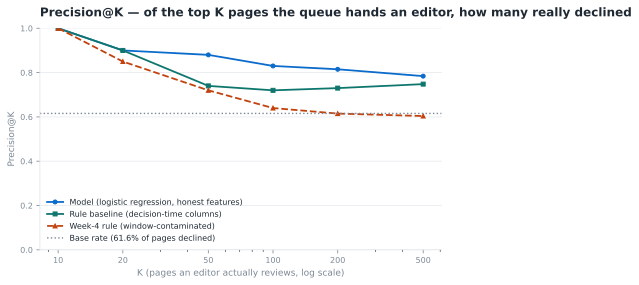

Ở mọi mức K mà một đội thật có thể xử lý, hàng đợi của mô hình nằm trên cả hai rule — còn rule tuần 4 tụt về đúng base rate.

=== honest_vs_leaky.svg ===


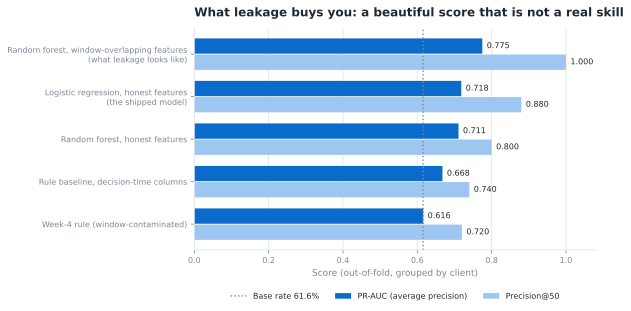

Cùng một model, chỉ khác feature set: các cột chồng lấn cửa sổ kết quả đẩy Precision@50 lên 1.000. Đó là thước đo của sự cám dỗ.

=== feature_importance.svg ===


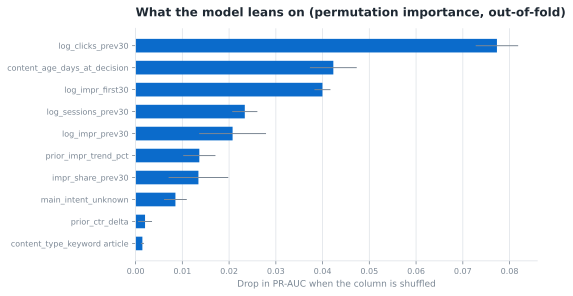

Số click ở cửa sổ trước là tín hiệu mạnh nhất; word_count gần như bằng 0 trong khung dự báo.

=== risk_deciles.svg ===


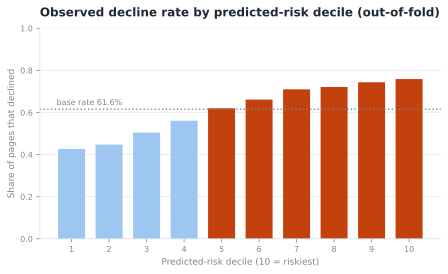

Decile rủi ro cao nhất suy giảm 75.9%, thấp nhất 42.7% — có tín hiệu, không có ranh giới sắc nét.

=== queue_reason_mix.svg ===


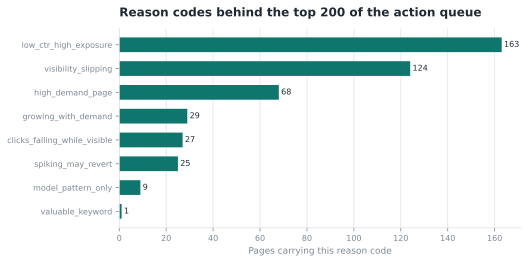

200 trang đầu không phải một loại việc: refresh, sửa metadata, và bảo vệ trang lớn là ba luồng khác nhau.

--- RECEIPTS (commit trong repo) ---
  work/outputs/capstone_coefficients.json
  work/outputs/capstone_importance.json
  work/outputs/capstone_metrics.json
  work/outputs/capstone_queue_summary.json
  work/outputs/capstone_queue_top20.json
  work/outputs/capstone_states.json
  work/outputs/evidence_audit.json
  work/outputs/monitoring_thresholds.json


In [7]:
from IPython.display import SVG, display as ipy_display

metrics = cp.main()

for name, caption in [
    ("precision_at_k.svg",
     "Ở mọi mức K mà một đội thật có thể xử lý, hàng đợi của mô hình nằm trên cả hai rule — "
     "còn rule tuần 4 tụt về đúng base rate."),
    ("honest_vs_leaky.svg",
     "Cùng một model, chỉ khác feature set: các cột chồng lấn cửa sổ kết quả đẩy Precision@50 lên 1.000. "
     "Đó là thước đo của sự cám dỗ."),
    ("feature_importance.svg",
     "Số click ở cửa sổ trước là tín hiệu mạnh nhất; word_count gần như bằng 0 trong khung dự báo."),
    ("risk_deciles.svg",
     "Decile rủi ro cao nhất suy giảm 75.9%, thấp nhất 42.7% — có tín hiệu, không có ranh giới sắc nét."),
    ("queue_reason_mix.svg",
     "200 trang đầu không phải một loại việc: refresh, sửa metadata, và bảo vệ trang lớn là ba luồng khác nhau."),
]:
    print(f"\n=== {name} ===")
    ipy_display(SVG(filename=str(cp.FIG / name)))
    print(caption)

print("\n--- RECEIPTS (commit trong repo) ---")
for f in sorted(os.listdir(cp.OUT)):
    if f.endswith(".json"):
        print(f"  work/outputs/{f}")

## ML-12 — Demo, social post, employer summary

### Dàn ý demo 5 phút

| Phút | Nội dung | Slide / màn hình |
|---|---|---|
| 0:00–0:45 | **Vấn đề.** Đội biên tập rà soát được 50 trang/tuần, danh mục có 30,000 trang. Câu hỏi không phải "trang nào tệ" mà là "trang nào xem trước". | Ảnh hàng đợi |
| 0:45–1:30 | **Khung bài toán.** Tách cửa sổ 90 ngày thành 3 đoạn 30 ngày; nhãn nằm ở đoạn cuối; chỉ đoạn 1–2 được làm feature. | Sơ đồ timeline |
| 1:30–2:30 | **Cú twist.** Rule tuần 4 của chính tôi (cũ + nhiều impressions) đạt ROC-AUC 0.500 — nó dựa vào hai cột nhiễm bẩn cửa sổ, trong đó 68% trang được cập nhật *bên trong* cửa sổ kết quả. | Bảng kết quả |
| 2:30–3:30 | **Kết quả trung thực.** P@50 = 0.88 so với 0.74 và base rate 0.616. Lift 1.43×. Thêm lại cột rò rỉ ⇒ 1.000, và đó là lý do tôi không công bố nó. | `honest_vs_leaky.svg` |
| 3:30–4:30 | **Đầu ra dùng được.** Hàng đợi có reason code, hành động, mức tin cậy; 200 trang đầu chia thành 3 luồng việc. | `queue_reason_mix.svg` |
| 4:30–5:00 | **Giới hạn.** Một snapshot, 30 client, không có thiết kế nhân quả. Đây là hỗ trợ quyết định, không phải lời hứa. | Slide limitations |

### Social post

> Tôi xây một mô hình xếp hạng trang cần rà soát trên 30,000 trang dữ liệu tìm kiếm thật — rồi phát hiện
> baseline của chính mình có ROC-AUC 0.500.
>
> Lý do: quy tắc "nội dung cũ + nhiều impressions" dựa vào `days_since_last_update`, mà 68% số trang
> được cập nhật *bên trong* chính cửa sổ kết quả tôi đang dự báo. Cột đó biết trước tương lai.
>
> Sau khi vứt mọi cột chồng lấn cửa sổ, mô hình hồi quy logistic đạt Precision@50 = 0.88 so với base rate
> 0.616 (lift 1.43×). Khiêm tốn — và thật. Thêm các cột rò rỉ trở lại thì lên 1.000; đó là con số tôi
> không được phép khoe.
>
> Bài học: một điểm số đẹp thường là một lỗi thiết kế đang tự khen mình. 📄 [link paper]

### Tóm tắt 3 câu cho nhà tuyển dụng

> Tôi xây một hệ thống xếp hạng ưu tiên rà soát nội dung trên 30,000 trang dữ liệu Google Search Console
> và GA4 thật (ẩn danh, 32 client), khung lại một snapshot cắt ngang thành một bài toán dự báo thật bằng
> cách tách cửa sổ 90 ngày thành ba đoạn 30 ngày và chỉ giữ những tín hiệu biết được tại thời điểm ra
> quyết định. Mô hình đạt Precision@50 = 0.88 so với 0.74 của rule minh bạch và 0.616 base rate, chấm
> out-of-fold trên split nhóm theo client — và tôi chứng minh được rằng baseline ban đầu của chính mình
> đạt ROC-AUC 0.500 vì rò rỉ cửa sổ thời gian. Đầu ra là một hàng đợi hành động có reason code cùng một
> paper công khai nêu rõ những gì công trình này *không* thể khẳng định.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.